# Description:
# This project analyzes customer churn patterns in a telecom company and builds
# machine learning models to predict which customers are likely to churn. We use
# the Telco Customer Churn dataset from Kaggle to identify key factors driving
# customer attrition and develop predictive models to help reduce churn rates.

# What I Did:
# 1. Exploratory Data Analysis (EDA) with visualizations
# 2. Data Preprocessing and Feature Engineering
# 3. Handled missing values and encoded categorical variables
# 4. Built multiple ML models (Logistic Regression, Random Forest, XGBoost)
# 5. Model evaluation and comparison
# 6. Feature importance analysis
# 7. Business insights and recommendations
#
# Libraries Used: pandas, numpy, scikit-learn, xgboost, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

#style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
# DATA LOADING AND INITIAL EXPLORATION
df = pd.read_csv(r'/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
print(df.head(10))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print(df.describe().T)

                 count       mean        std    min   25%    50%    75%  \
SeniorCitizen   7043.0   0.162147   0.368612   0.00   0.0   0.00   0.00   
tenure          7043.0  32.371149  24.559481   0.00   9.0  29.00  55.00   
MonthlyCharges  7043.0  64.761692  30.090047  18.25  35.5  70.35  89.85   

                   max  
SeniorCitizen     1.00  
tenure           72.00  
MonthlyCharges  118.75  


In [6]:
print(df.isnull().sum())
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn Rate: {(churn_counts['Yes'] / len(df)) * 100:.2f}%")


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


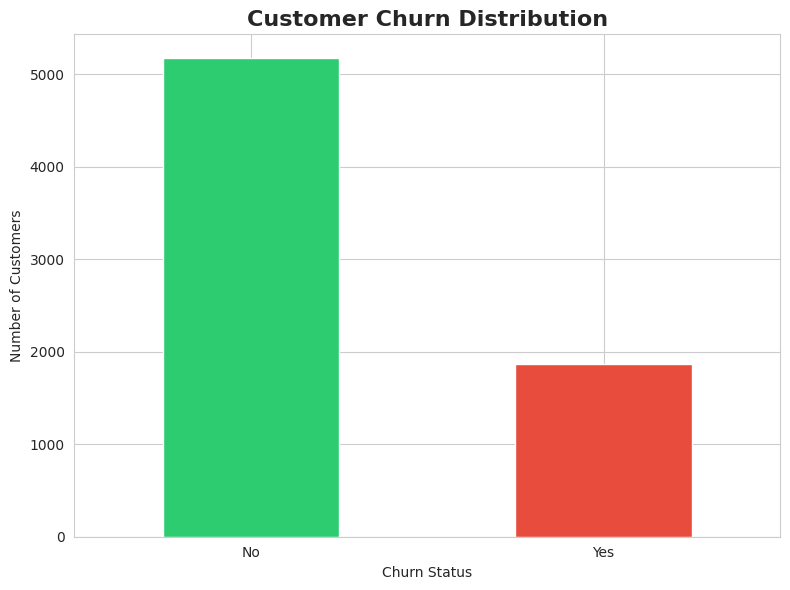

In [7]:
# EXPLORATORY DATA ANALYSIS (EDA)
# Plot 1: Churn Distribution
plt.figure(figsize=(8, 6))
churn_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

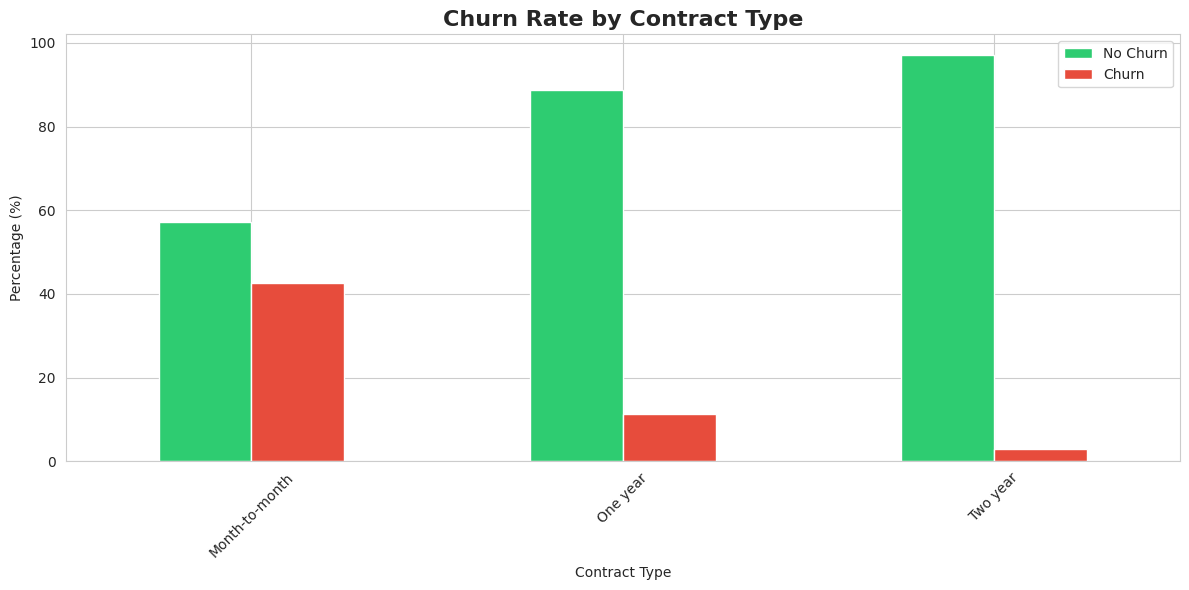

In [8]:
# Plot 2: Churn by Contract Type
plt.figure(figsize=(10, 6))
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=False, color=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

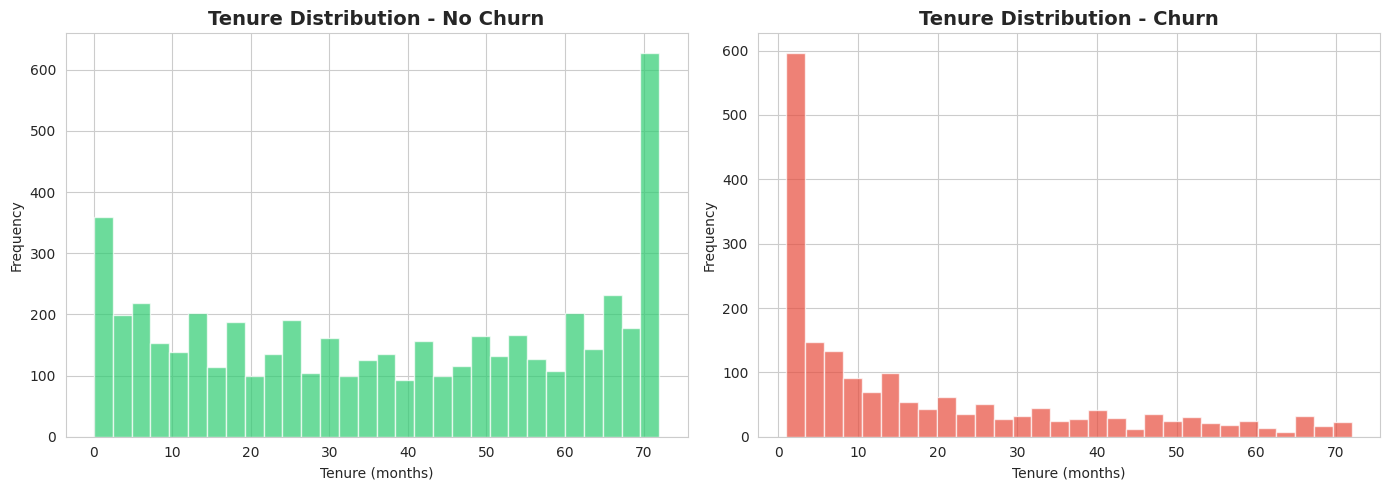

In [9]:

# Plot 3: Tenure Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[df['Churn'] == 'No']['tenure'].hist(bins=30, color='#2ecc71', alpha=0.7, ax=axes[0])
axes[0].set_title('Tenure Distribution - No Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Frequency')

df[df['Churn'] == 'Yes']['tenure'].hist(bins=30, color='#e74c3c', alpha=0.7, ax=axes[1])
axes[1].set_title('Tenure Distribution - Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('tenure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

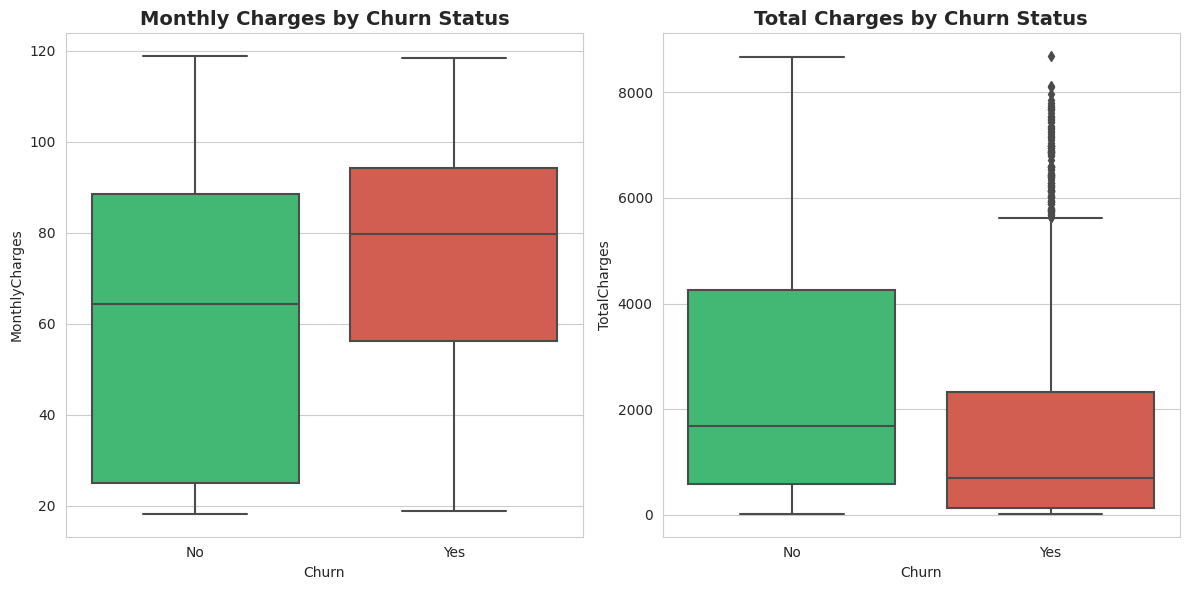

In [10]:
# Plot 4: Monthly Charges Distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')

plt.subplot(1, 2, 2)
# Convert TotalCharges to numeric for plotting
df_plot = df.copy()
df_plot['TotalCharges'] = pd.to_numeric(df_plot['TotalCharges'], errors='coerce')
df_plot = df_plot.dropna(subset=['TotalCharges'])
sns.boxplot(x='Churn', y='TotalCharges', data=df_plot, palette=['#2ecc71', '#e74c3c'])
plt.title('Total Charges by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charges_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


Creating Correlation Heatmap...


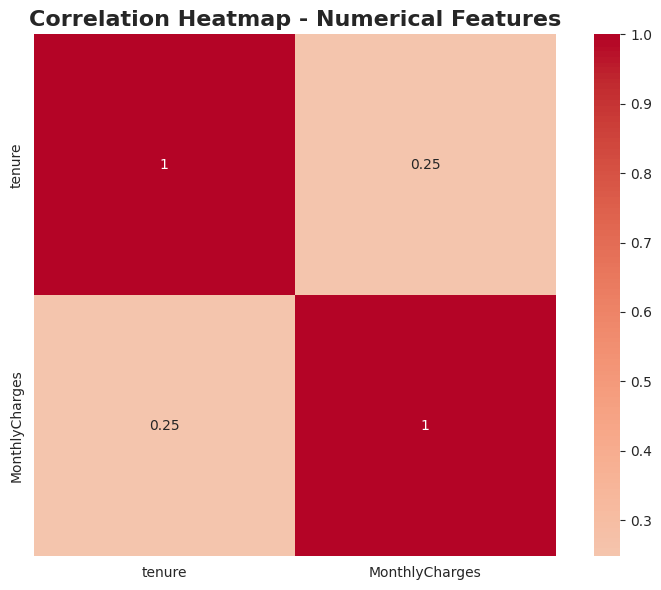

In [11]:
# Plot 5: Correlation Heatmap (for numerical features)
print("\nCreating Correlation Heatmap...")
numeric_cols = ['tenure', 'MonthlyCharges']
correlation_data = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap - Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# DATA PREPROCESSING
# Create a copy for preprocessing
df_processed = df.copy()

print("\nHandling TotalCharges column...")
df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')
df_processed['TotalCharges'].fillna(df_processed['TotalCharges'].median(), inplace=True)

df_processed.drop('customerID', axis=1, inplace=True)

print("✓ Encoding target variable...")
df_processed['Churn'] = df_processed['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('Churn') 

print(f"\nCategorical Features: {len(categorical_cols)}")
print(f"Numerical Features: {len(numerical_cols)}")

print("\nEncoding categorical variables...")
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

print("Data preprocessing completed!")


Handling TotalCharges column...
✓ Encoding target variable...

Categorical Features: 15
Numerical Features: 4

Encoding categorical variables...
Data preprocessing completed!


In [13]:
# FEATURE ENGINEERING
# 1. Average monthly charges per tenure
df_processed['AvgMonthlyCharges'] = df_processed['TotalCharges'] / (df_processed['tenure'] + 1)

# 2. Tenure groups
df_processed['TenureGroup'] = pd.cut(df_processed['tenure'], 
                                      bins=[0, 12, 24, 48, 72], 
                                      labels=[0, 1, 2, 3])

# 3. Charges groups
df_processed['ChargesGroup'] = pd.cut(df_processed['MonthlyCharges'], 
                                       bins=[0, 35, 70, 105, 120], 
                                       labels=[0, 1, 2, 3])

# Handle any remaining NaN values
print("\n✓ Handling any missing values...")
df_processed.fillna(df_processed.median(numeric_only=True), inplace=True)

print("Feature engineering completed!")
print(f"Total Features: {df_processed.shape[1] - 1}")
print(f"Missing values after engineering: {df_processed.isnull().sum().sum()}")


✓ Handling any missing values...
Feature engineering completed!
Total Features: 22
Missing values after engineering: 11


In [14]:
# MODEL PREPARATION
# Separate features and target
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Churn rate in target: {y.mean():.2%}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Check for NaN values before scaling
print("\nChecking for missing values...")
print(f"NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN in X_test: {X_test.isnull().sum().sum()}")

# Fill any remaining NaN values with median
if X_train.isnull().sum().sum() > 0:
    print("Found NaN values, filling with median...")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)
    print("✓ NaN values handled!")

# Scale numerical features
print("\n✓ Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Data preparation completed!")
print(f"Final X_train_scaled shape: {X_train_scaled.shape}")
print(f"Final X_test_scaled shape: {X_test_scaled.shape}")


Features shape: (7043, 22)
Target shape: (7043,)
Churn rate in target: 26.54%

Training set size: 5634
Testing set size: 1409

Checking for missing values...
NaN in X_train: 8
NaN in X_test: 3
Found NaN values, filling with median...
✓ NaN values handled!

✓ Scaling features...
 Data preparation completed!
Final X_train_scaled shape: (5634, 22)
Final X_test_scaled shape: (1409, 22)


In [15]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

# Store results
results = []

print("\nTraining and evaluating models...\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"✓ {name} completed!")
    print(f"  Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}\n")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
print(results_df.to_string(index=False))


Training and evaluating models...

Training Logistic Regression...
✓ Logistic Regression completed!
  Accuracy: 0.8034, Precision: 0.6601, Recall: 0.5348, F1: 0.5908, ROC-AUC: 0.8461

Training Decision Tree...
✓ Decision Tree completed!
  Accuracy: 0.7253, Precision: 0.4836, Recall: 0.5134, F1: 0.4981, ROC-AUC: 0.6572

Training Random Forest...
✓ Random Forest completed!
  Accuracy: 0.7807, Precision: 0.6132, Recall: 0.4706, F1: 0.5325, ROC-AUC: 0.8206

Training Gradient Boosting...
✓ Gradient Boosting completed!
  Accuracy: 0.8013, Precision: 0.6621, Recall: 0.5134, F1: 0.5783, ROC-AUC: 0.8432

Training XGBoost...
✓ XGBoost completed!
  Accuracy: 0.7757, Precision: 0.5948, Recall: 0.4866, F1: 0.5353, ROC-AUC: 0.8180


MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.803407   0.660066 0.534759  0.590842 0.846080
  Gradient Boosting  0.801278   0.662069 0.513369  0.578313 0.843230
      Random Forest  0.780696   0.


Best Model: Logistic Regression
ROC-AUC Score: 0.8461

Confusion Matrix:
[[932 103]
 [174 200]]


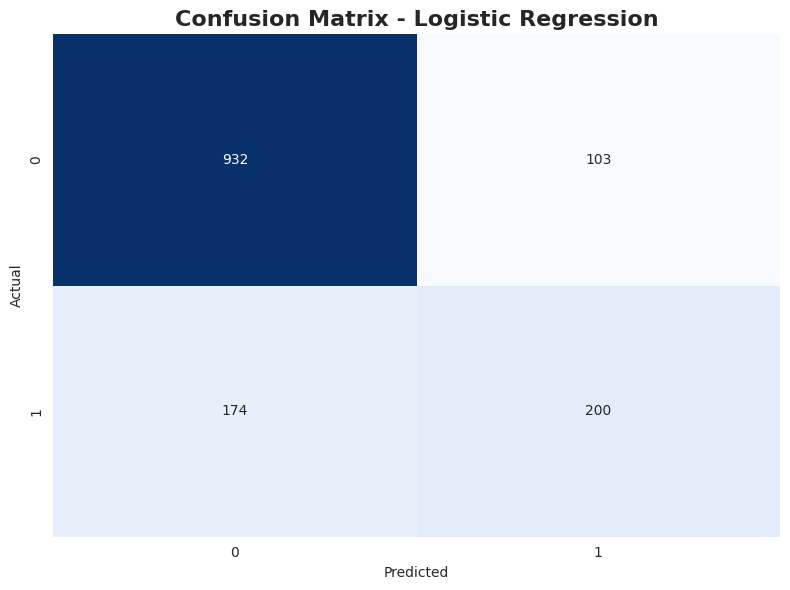


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



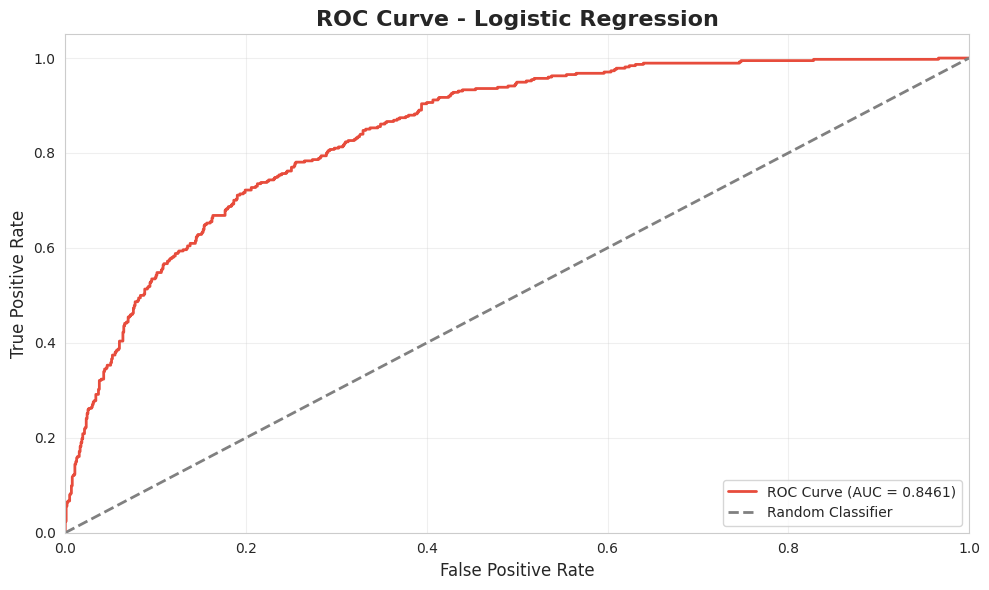

In [16]:
# BEST MODEL ANALYSIS

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"ROC-AUC Score: {results_df.iloc[0]['ROC-AUC']:.4f}")

y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
roc_auc = roc_auc_score(y_test, y_pred_proba_best)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {best_model_name}', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()


In [17]:
# FEATURE IMPORTANCE
# Get feature importance (works for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 15 Most Important Features:")
    print(feature_importance.head(15).to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'], color='#3498db')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance Score', fontsize=12)
    plt.title('Top 15 Most Important Features', fontsize=16, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()


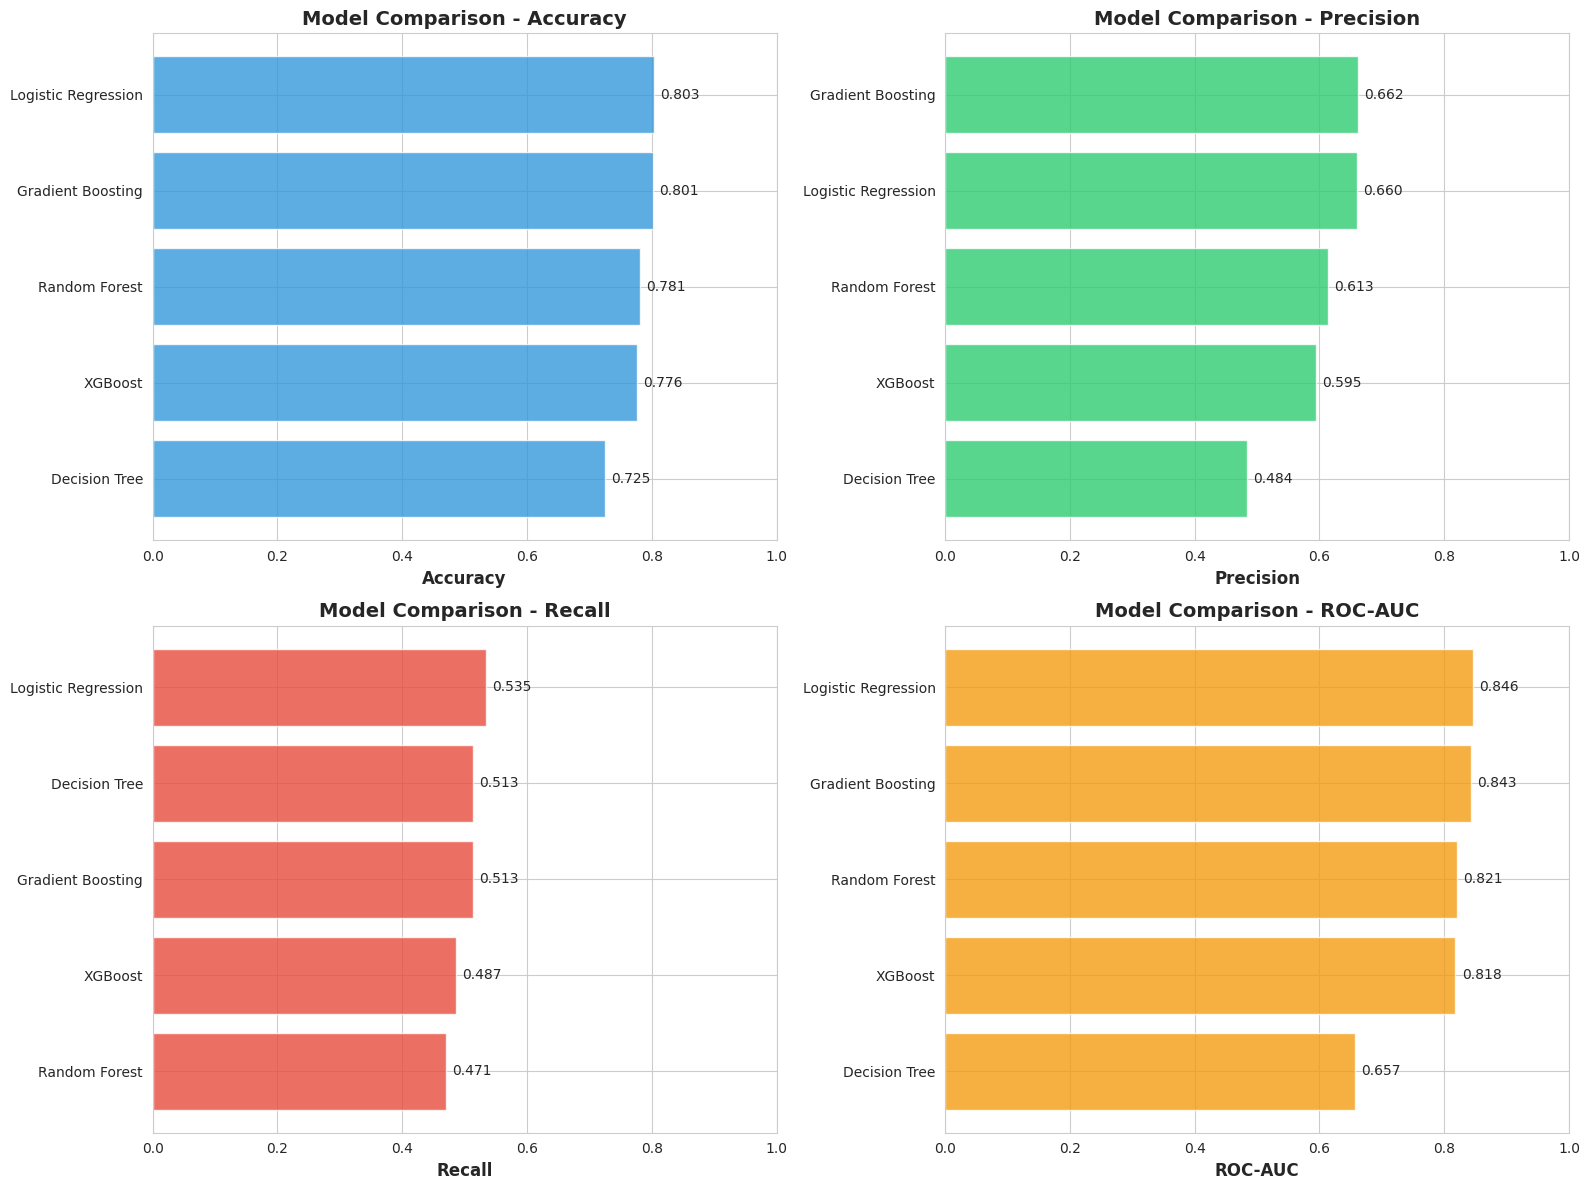

In [18]:
# MODEL COMPARISON VISUALIZATION

# Plot model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx // 2, idx % 2]
    data = results_df.sort_values(metric, ascending=True)
    ax.barh(data['Model'], data[metric], color=color, alpha=0.8)
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'Model Comparison - {metric}', fontsize=14, fontweight='bold')
    ax.set_xlim([0, 1])
    
    # Add value labels
    for i, v in enumerate(data[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# SAVE MODEL AND RESULTS
# Save model performance results
results_df.to_csv('model_performance_results.csv', index=False)
print("Model performance saved to 'model_performance_results.csv'")

# Save feature importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance.to_csv('feature_importance.csv', index=False)
    print("Feature importance saved to 'feature_importance.csv'")

print("PROJECT COMPLETED SUCCESSFULLY!")

Model performance saved to 'model_performance_results.csv'
PROJECT COMPLETED SUCCESSFULLY!
